In [1]:
%load_ext autoreload
%autoreload 2

This illustrates how to generate a test dataset for DIST-S1. See the markdown file in the tests directory for more information.

In [2]:
from pathlib import Path

import geopandas as gpd
import numpy as np
import rasterio
from affine import Affine
from dem_stitcher.rio_window import get_cropped_profile
from dist_s1_enumerator import enumerate_one_dist_s1_product, localize_rtc_s1_ts
from rasterio.plot import show
from rasterio.transform import xy
from tqdm import tqdm

/Users/cmarshak/miniforge3/envs/dist-s1-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
MAX_PRE_IMGS_PER_BURST=(8, 6, 6)

In [4]:
MGRS_TILE_ID = "10SGD"
TRACK_NUMBER = 137 # only looking at track 137 because cropping will lead to lots of random data
post_date = "2025-01-02" # 2025-01-02 OR 2024-12-21
PRIOR_DATASET = None # None or 'prior'

In [5]:
conditions = [((post_date == "2025-01-02") and (PRIOR_DATASET is None)),
              ((post_date == "2024-12-21") and (PRIOR_DATASET == 'prior'))]
assert sum(conditions) == 1

In [6]:
context_length = sum(MAX_PRE_IMGS_PER_BURST)
context_length

20

In [7]:
df_product = enumerate_one_dist_s1_product(
    MGRS_TILE_ID, track_number=TRACK_NUMBER, post_date=post_date, lookback_strategy='multi_window', max_pre_imgs_per_burst=MAX_PRE_IMGS_PER_BURST
)
df_product.head()

Searching for post-images for track 137 in MGRS tile 10SGD
Searching for pre-images for multi_window baseline
Lookback days (365, 730, 1095) and window days 365 with max pre-images per burst (8, 6, 6)


Windows: 100%|██████████████████████████████████████████| 3/3 [00:15<00:00,  5.28s/it]


,opera_id,jpl_burst_id,acq_dt,acq_date_for_mgrs_pass,polarizations,track_number,pass_id,url_crosspol,url_copol,geometry,mgrs_tile_id,acq_group_id_within_mgrs_tile,track_token,input_category
0,OPERA_L2_RTC-S1_T137-292318-IW1_20231004T01590...,T137-292318-IW1,2023-10-04 01:59:05+00:00,2023-10-04,VV+VH,137,593,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,"POLYGON ((-120.88304 33.88869, -119.8702 34.04...",10SGD,2,137,pre
1,OPERA_L2_RTC-S1_T137-292318-IW1_20231016T01590...,T137-292318-IW1,2023-10-16 01:59:05+00:00,2023-10-16,VV+VH,137,595,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,"POLYGON ((-120.88271 33.8883, -120.82789 33.89...",10SGD,2,137,pre
2,OPERA_L2_RTC-S1_T137-292318-IW1_20231028T01590...,T137-292318-IW1,2023-10-28 01:59:05+00:00,2023-10-28,VV+VH,137,597,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,"POLYGON ((-120.88219 33.88842, -119.86928 34.0...",10SGD,2,137,pre
3,OPERA_L2_RTC-S1_T137-292318-IW1_20231109T01590...,T137-292318-IW1,2023-11-09 01:59:04+00:00,2023-11-09,VV+VH,137,599,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,"POLYGON ((-120.88149 33.88809, -119.86853 34.0...",10SGD,2,137,pre
4,OPERA_L2_RTC-S1_T137-292318-IW1_20231121T01590...,T137-292318-IW1,2023-11-21 01:59:05+00:00,2023-11-21,VV+VH,137,601,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,"POLYGON ((-120.88482 33.88996, -119.87186 34.0...",10SGD,2,137,pre


The library is relies on disk `io` so every relative path has to be precise. We want the data paths:
   - to be in `test_data`
   - to be consistent with how `dist-s1-enumerator` works so we want to not touch `<MGRS_TILE_ID> / <TRACK_NUMBER>/...`

In [8]:
out_dir = Path(f'out_{context_length}')
out_dir.mkdir(exist_ok=True, parents=True)

# Download products

In [28]:
out_dir

PosixPath('out_20')

In [9]:
df_product_loc = localize_rtc_s1_ts(df_product, out_dir, max_workers=5)

In [33]:
df_product_loc[df_product_loc.jpl_burst_id == 'T137-292318-IW1'].shape

(21, 16)

# Localize Table

In [10]:
track_token = df_product_loc.track_token.iloc[0]
mgrs_tile_id = df_product_loc.mgrs_tile_id.iloc[0]
date_token = post_date

df_product.to_parquet(
    out_dir
    / f"{mgrs_tile_id}__{track_token}__{date_token}_dist_s1_inputs.parquet"
)

# Rewrite Rasters with Smaller Area

In [11]:
sample_loc_path = df_product_loc["loc_path_crosspol"].iloc[0]
with rasterio.open(sample_loc_path) as ds:
    X = ds.read(1)
    p = ds.profile

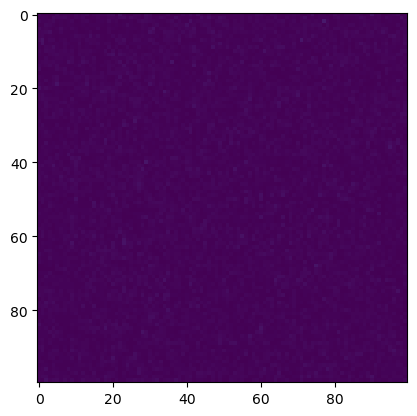

<Axes: >

In [12]:
SIZE = 100
sy = np.s_[600:600 + SIZE]
sx = np.s_[1100:1100 + SIZE]

show(X[sy, sx], vmin=0, vmax=0.15)

Again, we are making sure that we put was once in `out` into `test_data/cropped`.

In [43]:
if PRIOR_DATASET is None:
    cropped_data_dir = Path('test_data/cropped')
elif isinstance(PRIOR_DATASET, str):
    cropped_data_dir = Path(f'test_data/cropped_{PRIOR_DATASET}')
else:
    raise ValueError('PRIOR_DATASET must be string')
cropped_data_dir.mkdir(exist_ok=True, parents=True)
cropped_data_dir

PosixPath('test_data/cropped')

WARNING: This notebook will overwrite the existing data in `test_data/cropped`.

In [44]:
def crop_and_serialize_data(data_path: str) -> Path:
    src_path = Path(data_path)
    out_path = cropped_data_dir / src_path.relative_to(out_dir)
    out_parent = out_path.parent
    out_parent.mkdir(exist_ok=True, parents=True)
    with rasterio.open(src_path) as ds:
        X = ds.read(1)
        p = ds.profile
    p_c = get_cropped_profile(p, sx, sy)
    with rasterio.open(out_path, "w", **p_c) as ds:
        ds.write(X[sy, sx], 1)
    return str(out_path)

In [45]:
new_crosspol_paths = list(map(crop_and_serialize_data, df_product_loc.loc_path_crosspol[:]))
new_copol_paths = list(map(crop_and_serialize_data, df_product_loc.loc_path_copol[:]))

In [46]:
def update_path(data_path: str) -> str:
    src_path = Path(data_path)
    out_path = cropped_data_dir / src_path.relative_to(out_dir)
    if not out_path.exists():
        print(out_path)
    return str(out_path)

In [47]:
df_product_loc_small = df_product_loc.copy()
df_product_loc_small["loc_path_copol"] = df_product_loc.loc_path_copol.map(update_path)
df_product_loc_small["loc_path_crosspol"] = df_product_loc.loc_path_crosspol.map(update_path)


In [48]:
df_product_loc_small.to_parquet(
    cropped_data_dir / f"{mgrs_tile_id}__{track_token}__{date_token}_dist_s1_inputs.parquet"
)

# For Runconfig Testing 

See `testing/test_run_config_model.py` in `dist-s1`.

In [49]:
sorted(df_product.jpl_burst_id.unique())

['T137-292318-IW1',
 'T137-292318-IW2',
 'T137-292319-IW1',
 'T137-292319-IW2',
 'T137-292320-IW1',
 'T137-292320-IW2',
 'T137-292321-IW1',
 'T137-292321-IW2',
 'T137-292322-IW1',
 'T137-292322-IW2',
 'T137-292323-IW1',
 'T137-292323-IW2',
 'T137-292324-IW1',
 'T137-292324-IW2',
 'T137-292325-IW1']

In [50]:
IND_BURST = df_product.jpl_burst_id == "T137-292319-IW2"
IND_PRE = df_product.input_category == "pre"

pre_dts = sorted(df_product[IND_PRE & IND_BURST].acq_dt.tolist())
[dt.strftime("%Y%m%dT%H%M%S") for dt in pre_dts]

['20211119T015858',
 '20211125T015816',
 '20211201T015857',
 '20211207T015815',
 '20211213T015857',
 '20211219T015814',
 '20221102T015904',
 '20221114T015904',
 '20221126T015904',
 '20221208T015903',
 '20221220T015902',
 '20230101T015902',
 '20231004T015909',
 '20231016T015909',
 '20231028T015909',
 '20231109T015908',
 '20231121T015908',
 '20231203T015908',
 '20231215T015907',
 '20231227T015906']

In [51]:
l = df_product[IND_PRE & IND_BURST]["url_copol"].map(
    lambda url: url.split("/")[-1]
).tolist()
sorted(l)

['OPERA_L2_RTC-S1_T137-292319-IW2_20211119T015858Z_20250830T120333Z_S1A_30_v1.0_VV.tif',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20211125T015816Z_20250830T093052Z_S1B_30_v1.0_VV.tif',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20211201T015857Z_20250830T065219Z_S1A_30_v1.0_VV.tif',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20211207T015815Z_20250830T041332Z_S1B_30_v1.0_VV.tif',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20211213T015857Z_20250830T031828Z_S1A_30_v1.0_VV.tif',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20211219T015814Z_20250829T223306Z_S1B_30_v1.0_VV.tif',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20221102T015904Z_20250222T020850Z_S1A_30_v1.0_VV.tif',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20221114T015904Z_20250222T234616Z_S1A_30_v1.0_VV.tif',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20221126T015904Z_20250228T045856Z_S1A_30_v1.0_VV.tif',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20221208T015903Z_20250301T173913Z_S1A_30_v1.0_VV.tif',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20221220T015902Z_20250302T062310Z_S1A_30_v1.0_VV.tif',
 'OPERA_L2_RTC-S1_T13

In [52]:
l = df_product[IND_PRE & IND_BURST]["url_crosspol"].map(
    lambda url: url.split("/")[-1]
).tolist()
l = sorted(l)
l

['OPERA_L2_RTC-S1_T137-292319-IW2_20211119T015858Z_20250830T120333Z_S1A_30_v1.0_VH.tif',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20211125T015816Z_20250830T093052Z_S1B_30_v1.0_VH.tif',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20211201T015857Z_20250830T065219Z_S1A_30_v1.0_VH.tif',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20211207T015815Z_20250830T041332Z_S1B_30_v1.0_VH.tif',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20211213T015857Z_20250830T031828Z_S1A_30_v1.0_VH.tif',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20211219T015814Z_20250829T223306Z_S1B_30_v1.0_VH.tif',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20221102T015904Z_20250222T020850Z_S1A_30_v1.0_VH.tif',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20221114T015904Z_20250222T234616Z_S1A_30_v1.0_VH.tif',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20221126T015904Z_20250228T045856Z_S1A_30_v1.0_VH.tif',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20221208T015903Z_20250301T173913Z_S1A_30_v1.0_VH.tif',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20221220T015902Z_20250302T062310Z_S1A_30_v1.0_VH.tif',
 'OPERA_L2_RTC-S1_T13

In [53]:
IND_POST = df_product.input_category == "post"

pre_dts = df_product[IND_POST & IND_BURST].acq_dt.tolist()
[dt.strftime("%Y%m%dT%H%M%S") for dt in pre_dts]

['20250102T015901']

In [54]:
df_product[IND_POST & IND_BURST]["url_copol"].map(
    lambda url: url.split("/")[-1]
).tolist()

['OPERA_L2_RTC-S1_T137-292319-IW2_20250102T015901Z_20250102T190143Z_S1A_30_v1.0_VV.tif']

In [55]:
df_product[IND_POST & IND_BURST]["url_crosspol"].map(
    lambda url: url.split("/")[-1]
).tolist()

['OPERA_L2_RTC-S1_T137-292319-IW2_20250102T015901Z_20250102T190143Z_S1A_30_v1.0_VH.tif']

## RunConfig

In [57]:
from dist_s1.data_models.runconfig_model import RunConfigData

config = RunConfigData.from_product_df(df_product_loc_small, dst_dir='test_data', model_source='transformer_v1_32', device='cpu', max_pre_imgs_per_burst_mw=MAX_PRE_IMGS_PER_BURST)
config.to_yaml('run_config.yml')